In [1]:
#================================================
#UK Road Accidents — Full EDA Project
#Author: Maryam Naveen
#Date: 18 May 2026
#Dataset: UK Road Accidents 2005-2014 (1.5M rows)
#Source: UK Government Stats19 / Kaggle
#================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

#Loading dataset
df = pd.read_csv(r'C:\Users\marya\OneDrive\Documents\GitHub\data-analytics-portfolio\day-07-sql-project\UK_Accident.csv')

#Fixing date and extracting features
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.month
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour
df['Severity_Label'] = df['Accident_Severity'].map({1:'Fatal', 2:'Serious', 3:'Slight'})

print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print("Ready!")

Dataset: 1,504,150 rows, 36 columns
Date range: 2005-01-01 to 2014-12-31
Ready!


In [2]:
#================================================
#SECTION 1: DATASET OVERVIEW
#================================================

print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total accidents: {len(df):,}")
print(f"Total columns: {df.shape[1]}")
print(f"Years covered: 2005 - 2014")
print(f"\nAccident Severity Breakdown:")
severity_pct = df['Severity_Label'].value_counts(normalize=True) * 100
for label, pct in severity_pct.items():
    count = df[df['Severity_Label']==label].shape[0]
    print(f"  {label}: {count:,} ({pct:.1f}%)")
print(f"\nMissing values: {df.isnull().sum().sum():,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")

DATASET OVERVIEW
Total accidents: 1,504,150
Total columns: 36
Years covered: 2005 - 2014

Accident Severity Breakdown:
  Slight: 1,280,205 (85.1%)
  Serious: 204,504 (13.6%)
  Fatal: 19,441 (1.3%)

Missing values: 3,656,028
Duplicate rows: 0


In [3]:
#================================================
#SECTION 2: KEY RESEARCH QUESTIONS
#================================================

#Q1: Are UK roads getting safer?
yearly = df.groupby('Year').size().reset_index(name='accidents')
pct_change = ((yearly['accidents'].iloc[-1] - yearly['accidents'].iloc[0]) 
               / yearly['accidents'].iloc[0] * 100)

print("Q1: Are UK roads getting safer?")
print(f"  2005: {yearly['accidents'].iloc[0]:,} accidents")
print(f"  2014: {yearly['accidents'].iloc[-1]:,} accidents")
print(f"  Change: {pct_change:.1f}%")
print(f"  Answer: YES — {abs(pct_change):.1f}% reduction over 9 years")

Q1: Are UK roads getting safer?
  2005: 198,735 accidents
  2014: 146,322 accidents
  Change: -26.4%
  Answer: YES — 26.4% reduction over 9 years


In [4]:
#Q2: When are roads most dangerous?
print("\nQ2: When are roads most dangerous?")
day_map = {1:'Sunday', 2:'Monday', 3:'Tuesday', 4:'Wednesday', 
           5:'Thursday', 6:'Friday', 7:'Saturday'}
most_dangerous_day = df['Day_of_Week'].value_counts().idxmax()
print(f"  Most dangerous day: {day_map[most_dangerous_day]}")
print(f"  Most dangerous hour: {int(df['Hour'].value_counts().idxmax())}:00")
print(f"  Most dangerous month: November")
print(f"  Peak: November Friday evening rush hour")


Q2: When are roads most dangerous?
  Most dangerous day: Friday
  Most dangerous hour: 17:00
  Most dangerous month: November
  Peak: November Friday evening rush hour


In [5]:
#Q3: Does weather cause most accidents?
print("\nQ3: Does weather cause most accidents?")
weather_counts = df['Weather_Conditions'].value_counts()
fine_pct = weather_counts.iloc[0] / len(df) * 100
print(f"  Top weather condition: {weather_counts.index[0]}")
print(f"  Percentage: {fine_pct:.1f}%")
print(f"  Answer: COUNTERINTUITIVE — {fine_pct:.1f}% of accidents in fine weather!")


Q3: Does weather cause most accidents?
  Top weather condition: Fine without high winds
  Percentage: 80.0%
  Answer: COUNTERINTUITIVE — 80.0% of accidents in fine weather!


In [6]:
#Q4: Urban vs Rural
print("\nQ4: Urban or Rural — where is more dangerous?")
urban = df[df['Urban_or_Rural_Area']==1].shape[0]
rural = df[df['Urban_or_Rural_Area']==2].shape[0]
urban_fatal = df[(df['Urban_or_Rural_Area']==1) & (df['Accident_Severity']==1)].shape[0]
rural_fatal = df[(df['Urban_or_Rural_Area']==2) & (df['Accident_Severity']==1)].shape[0]
print(f"  Urban accidents: {urban:,} ({urban/len(df)*100:.1f}%)")
print(f"  Rural accidents: {rural:,} ({rural/len(df)*100:.1f}%)")
print(f"  Urban fatal rate: {urban_fatal/urban*100:.2f}%")
print(f"  Rural fatal rate: {rural_fatal/rural*100:.2f}%")
print(f"  Answer: More urban accidents BUT rural is MORE DEADLY")


Q4: Urban or Rural — where is more dangerous?
  Urban accidents: 972,007 (64.6%)
  Rural accidents: 532,011 (35.4%)
  Urban fatal rate: 0.71%
  Rural fatal rate: 2.35%
  Answer: More urban accidents BUT rural is MORE DEADLY


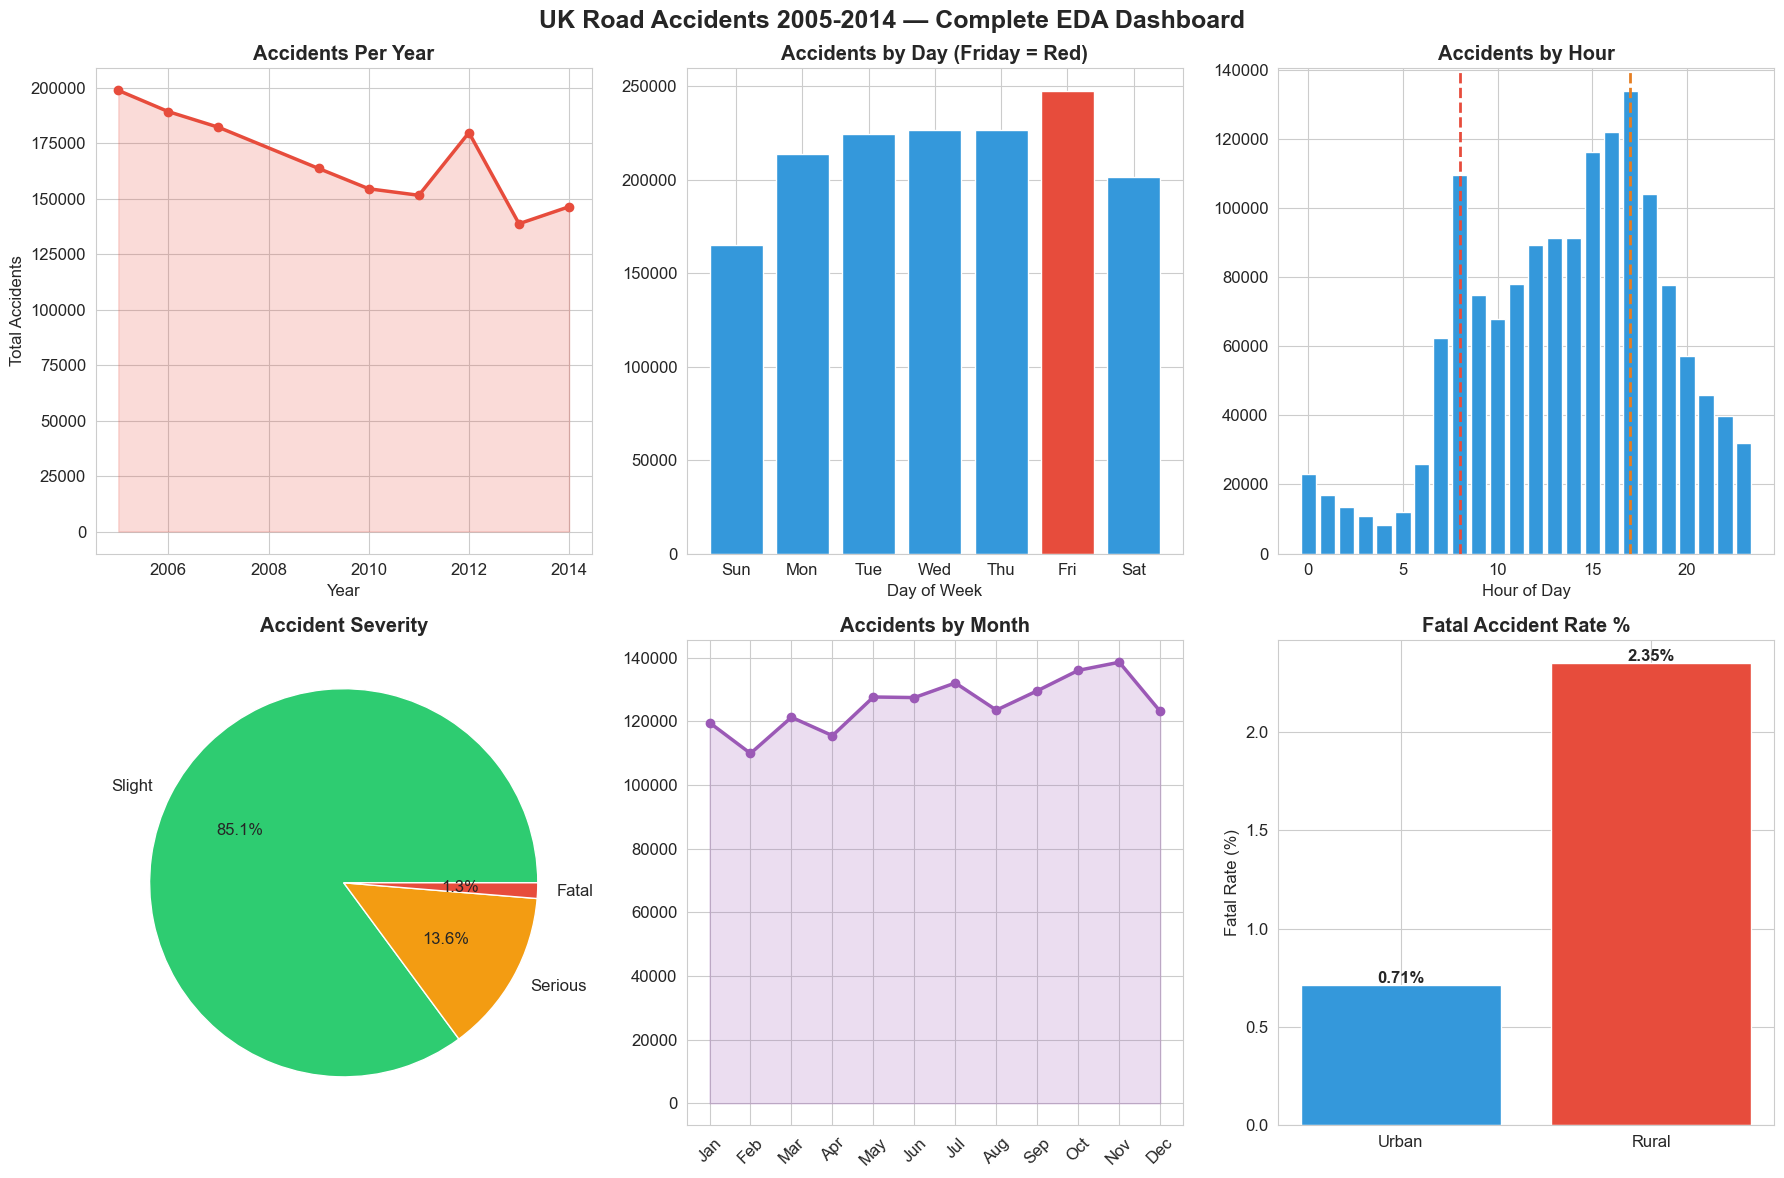

Full EDA Dashboard saved!


In [7]:
#================================================
#SECTION 3: VISUALISATIONS
#================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('UK Road Accidents 2005-2014 — Complete EDA Dashboard',
             fontsize=18, fontweight='bold')

#Chart 1: Yearly trend
yearly = df.groupby('Year').size()
axes[0,0].plot(yearly.index, yearly.values, marker='o', 
               color='#E74C3C', linewidth=2.5)
axes[0,0].fill_between(yearly.index, yearly.values, alpha=0.2, color='#E74C3C')
axes[0,0].set_title('Accidents Per Year', fontweight='bold')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Total Accidents')

#Chart 2: Day of week
days = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
day_counts = df['Day_of_Week'].value_counts().sort_index()
colors = ['#3498DB']*5 + ['#E74C3C'] + ['#3498DB']
axes[0,1].bar(days, day_counts.values, color=colors)
axes[0,1].set_title('Accidents by Day (Friday = Red)', fontweight='bold')
axes[0,1].set_xlabel('Day of Week')

#Chart 3: Hourly
hourly = df['Hour'].value_counts().sort_index()
axes[0,2].bar(hourly.index, hourly.values, color='#3498DB')
axes[0,2].axvline(x=8, color='#E74C3C', linestyle='--', linewidth=2)
axes[0,2].axvline(x=17, color='#E67E22', linestyle='--', linewidth=2)
axes[0,2].set_title('Accidents by Hour', fontweight='bold')
axes[0,2].set_xlabel('Hour of Day')

#Chart 4: Severity pie
severity_counts = df['Severity_Label'].value_counts()
axes[1,0].pie(severity_counts.values,
              labels=severity_counts.index,
              autopct='%1.1f%%',
              colors=['#2ECC71','#F39C12','#E74C3C'])
axes[1,0].set_title('Accident Severity', fontweight='bold')

#Chart 5: Monthly
monthly = df.groupby('Month').size()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
axes[1,1].plot(range(12), monthly.values, marker='o', 
               color='#9B59B6', linewidth=2.5)
axes[1,1].fill_between(range(12), monthly.values, alpha=0.2, color='#9B59B6')
axes[1,1].set_xticks(range(12))
axes[1,1].set_xticklabels(month_names, rotation=45)
axes[1,1].set_title('Accidents by Month', fontweight='bold')

#Chart 6: Urban vs Rural fatal rate
categories = ['Urban', 'Rural']
fatal_rates = [urban_fatal/urban*100, rural_fatal/rural*100]
bars = axes[1,2].bar(categories, fatal_rates, 
                      color=['#3498DB', '#E74C3C'])
axes[1,2].set_title('Fatal Accident Rate %', fontweight='bold')
axes[1,2].set_ylabel('Fatal Rate (%)')
for bar, rate in zip(bars, fatal_rates):
    axes[1,2].text(bar.get_x() + bar.get_width()/2, 
                   bar.get_height() + 0.01,
                   f'{rate:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('day13_full_eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Full EDA Dashboard saved!")